In [1]:
# %matplotlib widget
import matplotlib.pyplot as plt
import matplotlib as mpl
import h5py
import numpy as np
import json
from datetime import datetime
from Allineamento_v2 import *

In [2]:
run_alignement = 730381 
data_path =f'/eos/project/i/insulab-como/testBeam/TB_2025_06_T9_epBOOST/HDF5/run{run_alignement}.h5'

# print('opening ', data_path) 
pos = []
phs = []
tmis =[]
qtots =[]
nclus = []
info_pluss =[]
xinfos =[]

with h5py.File(data_path, 'r', libver='latest', swmr=True) as hf:
    # print(hf.keys())
    hf["xpos"].shape
    keys = list(hf.keys())
    pos.append(np.array(hf['xpos']))
    phs.append(np.array(hf['digiPH'])) # from 24
    tmis.append(np.array(hf['digiTime'])) # from 24
    qtots.append(np.array(hf['qtot'])) # from 24
    nclus.append(np.array(hf['nclu'])) # from 24
    info_pluss.append(np.array(hf['info_plus']))
    xinfos.append(np.array(hf['xinfo']))
    #for k in hf.keys():
    #    comand = f'{k} = np.array(hf["{k}"])'
        # print(comand)
    #  exec(comand)
xpos = np.concatenate(pos,axis=0)
ph = np.concatenate(phs,axis=0)
tm = np.concatenate(tmis,axis=0)
qtot = np.concatenate(qtots,axis=0)
nclu = np.concatenate(nclus,axis=0)
info_plus = np.concatenate(info_pluss,axis=0)
xinfo = np.concatenate(xinfos,axis=0)
# print('xpos shape', xpos.shape)
# print('N spill: ', info_plus[:,0][-1])
# print(np.unique(xinfo[:,1]))

logic_pos = (xpos[:, :6] > -1) & (xpos[:, :6] < 15)
logic2 = logic_pos.all(axis = 1)
xpos= xpos[logic2]
ph= ph[logic2]
tm= tm[logic2]
qtot= qtot[logic2]
nclu= nclu[logic2]
info_plus= info_plus[logic2]
xinfo= xinfo[logic2]

x1 = xpos[:,0]
y1 = xpos[:,1]
x2 = xpos[:,2] 
y2 = xpos[:,3] 
x3 = xpos[:,4]
y3 = xpos[:,5]

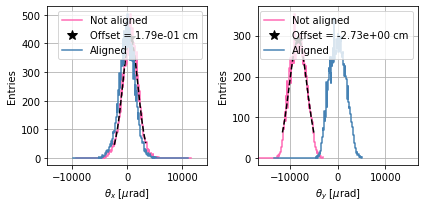

[0.17853857345868965, -2.733923881801258]


In [3]:
# d12 = 330 ## cm
# d23 = 53.2+626
# d1c = 330 + 53.2 #cm
# dc3 = 626 
# d1calo = d1c + 779.2 


# === OFFSET e DISTANZE ===
d12 = 330  # cm
d23 = 53.2 + 626  ##66.8
d1c = 330 + 53.2  # cm
dc3 = 626 ## 10.7 
d1calo = d1c + 779.2



offset_21, div21 =  align(x2, y2, x1, y1, d12, plotter=True)

print(offset_21)

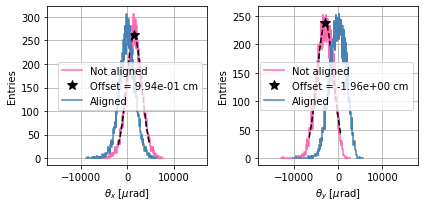

[0.9942923168277504, -1.9629701995444038]


In [4]:
offset_23, div23 =  align(x2, y2, x3, y3, d23, plotter=True)
print(offset_23)
